# Séries Temporais — ACF, PACF e Testes de Estacionaridade

## Objetivos da aula

Ao final deste notebook, você deverá ser capaz de:

- interpretar a **ACF (Autocorrelation Function)**;
- interpretar a **PACF (Partial Autocorrelation Function)**;
- reconhecer padrões de ACF/PACF associados a diferentes estruturas de dependência temporal;
- diferenciar **autocorrelação**, **autocorrelação parcial** e **estacionaridade**;
- utilizar os testes **Dickey-Fuller (DF)** e **Augmented Dickey-Fuller (ADF)** como evidências para avaliar estacionaridade;
- entender por que **ruído branco** e **passeio aleatório** são exemplos importantes, mas não devem ser o ponto de partida para a interpretação dos correlogramas.

> **Importante:** os exemplos de ruído branco e passeio aleatório dos notebooks originais foram mantidos e aparecem ao final, como solicitado.

## 1. Preparação do ambiente

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima_process import ArmaProcess

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (15, 5)

np.random.seed(42)

# 2. Antes do correlograma: o que estamos procurando?

Uma série temporal não é apenas uma sequência de números. A ordem temporal importa.

Quando observamos uma série, uma pergunta fundamental é:

> **O valor observado hoje contém informação sobre valores observados anteriormente?**

Essa dependência pode ser investigada por meio da **autocorrelação**.

Por exemplo, se valores altos tendem a ser seguidos por valores altos e valores baixos tendem a ser seguidos por valores baixos, existe evidência de dependência temporal.

Entretanto, uma série pode apresentar padrões visuais — como tendência ou sazonalidade — que produzem autocorrelações elevadas sem que isso represente necessariamente uma estrutura estacionária adequada para modelagem.

Por isso, a leitura deve seguir uma sequência:

1. observar a série;
2. identificar possíveis padrões de tendência, sazonalidade e variabilidade;
3. analisar ACF e PACF;
4. avaliar estacionaridade;
5. somente depois pensar na estrutura de modelagem.

# 3. Exemplo 1 — Tendência + ruído

Vamos começar com um exemplo simples: uma tendência determinística acrescida de ruído.

A tendência faz com que observações próximas no tempo sejam parecidas. Consequentemente, a ACF pode apresentar valores elevados em vários lags.

### Atenção

Uma ACF elevada **não significa automaticamente** que temos um processo estacionário com forte dependência temporal.

A tendência pode ser responsável por grande parte dessa autocorrelação.

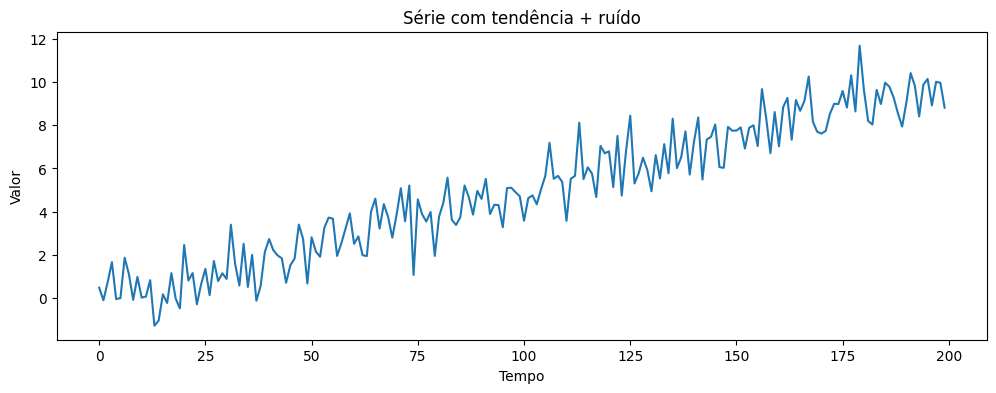

In [2]:
n = 200
t = np.arange(n)

trend = 0.05 * t
noise = np.random.normal(0, 1, n)
serie_tendencia = trend + noise

plt.figure(figsize=(12, 4))
plt.plot(serie_tendencia)
plt.title("Série com tendência + ruído")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

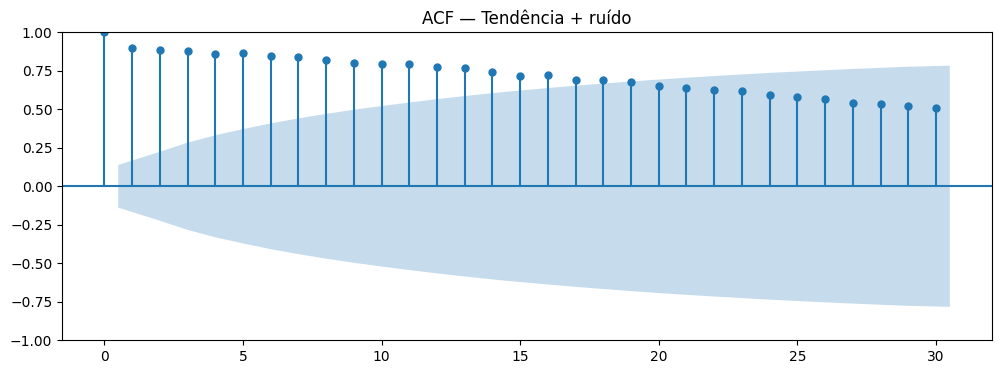

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(serie_tendencia, lags=30, ax=ax)
ax.set_title("ACF — Tendência + ruído")
plt.show()

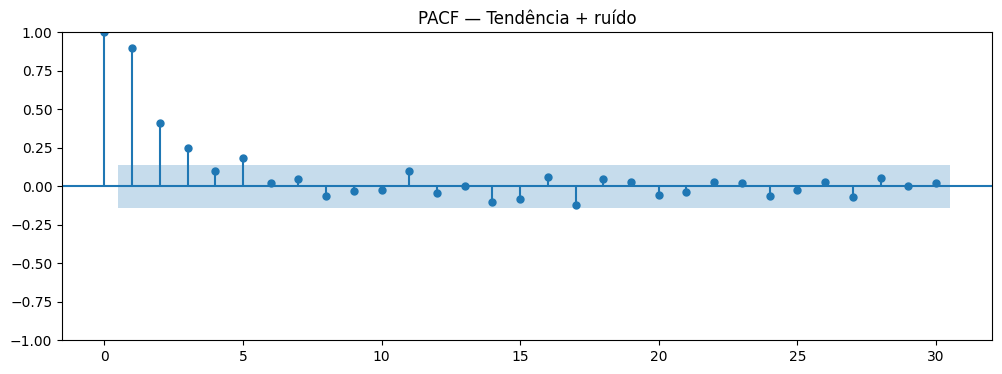

In [4]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(serie_tendencia, lags=30, ax=ax, method="ywm")
ax.set_title("PACF — Tendência + ruído")
plt.show()

## Interpretação

Observe que a tendência pode gerar uma ACF com decaimento lento.

Esse é um primeiro alerta:

> **Decaimento lento da ACF pode ser um indício de não estacionaridade.**

Mas ACF/PACF não devem ser usados isoladamente para concluir que uma série é ou não estacionária. É justamente por isso que os testes de raiz unitária serão apresentados posteriormente.

# 4. Exemplo 2 — Sazonalidade

Agora vamos criar uma série com sazonalidade anual.

A sazonalidade cria dependência entre observações separadas por um período específico. Para dados mensais com sazonalidade anual, esperamos encontrar informação relevante em torno dos lags 12, 24, 36, ...

Esse padrão é muito importante na interpretação da ACF.

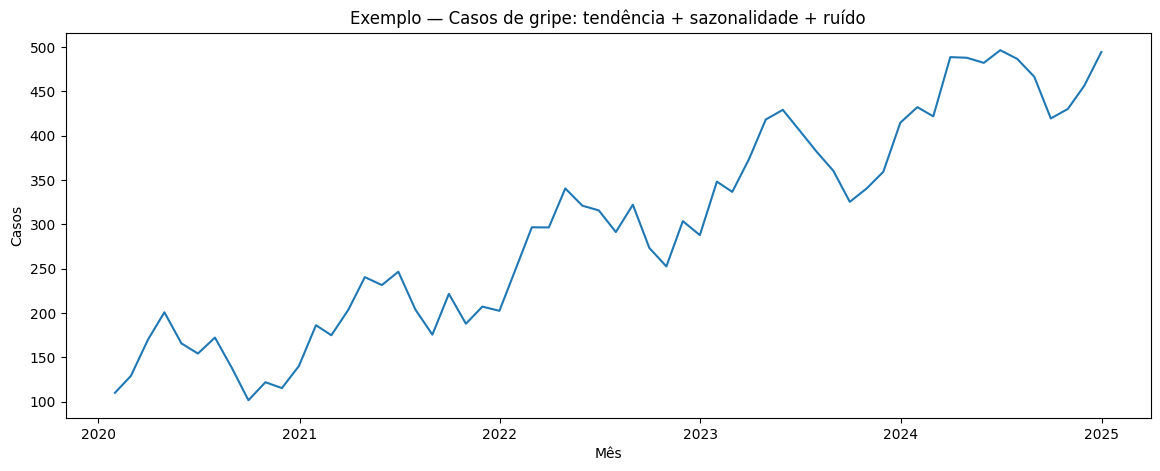

In [5]:
np.random.seed(42)

n_meses = 60
meses = pd.date_range(start="2020-01-01", periods=n_meses, freq="ME")

trend = np.linspace(100, 500, n_meses)
seasonal = 50 * np.sin(2 * np.pi * np.arange(n_meses) / 12)
noise = np.random.normal(loc=0, scale=20, size=n_meses)

cases = trend + seasonal + noise

df_cases = pd.DataFrame({
    "Month": meses,
    "Cases": cases
})

plt.figure(figsize=(14, 5))
plt.plot(df_cases["Month"], df_cases["Cases"])
plt.title("Exemplo — Casos de gripe: tendência + sazonalidade + ruído")
plt.xlabel("Mês")
plt.ylabel("Casos")
plt.show()

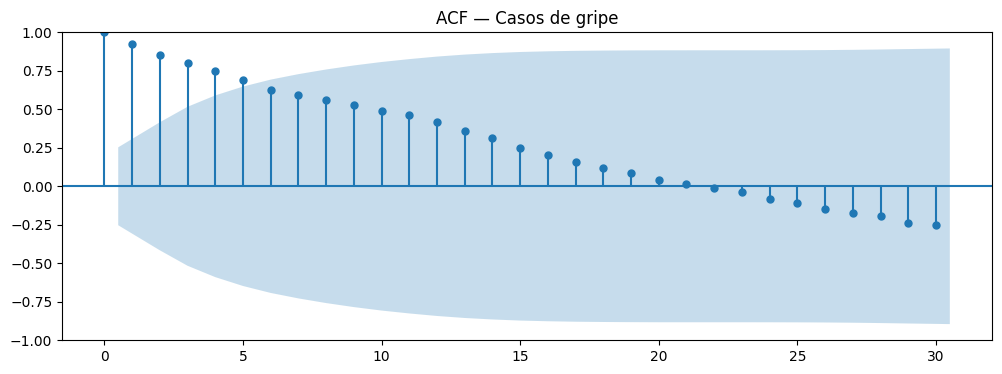

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df_cases["Cases"], lags=30, ax=ax)
ax.set_title("ACF — Casos de gripe")
plt.show()

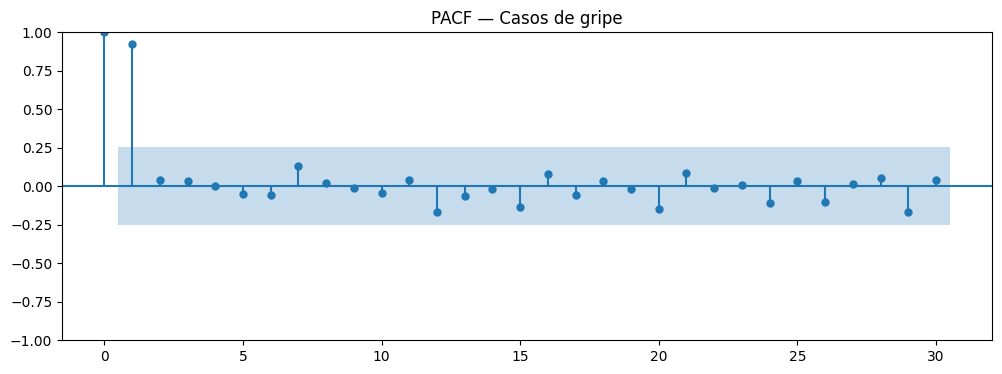

In [7]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(df_cases["Cases"], lags=30, ax=ax, method="ywm")
ax.set_title("PACF — Casos de gripe")
plt.show()

## Interpretação da sazonalidade no correlograma

Neste exemplo, a ACF pode apresentar picos associados ao período sazonal.

Para uma série mensal com sazonalidade anual:

- **lag 1** → distância de um mês;
- **lag 12** → distância de um ano;
- **lag 24** → distância de dois anos.

A presença de picos nos lags sazonais é uma pista importante de sazonalidade.

> A ACF ajuda a revelar a periodicidade porque compara a série com versões dela mesma deslocadas no tempo.

# 5. ACF — Função de Autocorrelação

A **ACF** mede a correlação entre a série e uma versão dela mesma defasada.



> **Quanto o valor de uma observação está associado ao valor da mesma série k períodos antes?**

### Como ler o gráfico

- **Lag 0:** a correlação é sempre 1, pois estamos comparando a série consigo mesma.
- **Lag 1:** relação entre X_t e X_t-1.
- **Lag 2:** relação entre X_t e X_t-2.
- e assim sucessivamente.

As barras que ultrapassam os limites de confiança sugerem autocorrelação estatisticamente diferente de zero naquele lag.

### Um cuidado importante

A ACF em um determinado lag é uma **correlação marginal**. Ela não elimina o efeito dos lags intermediários.

É aí que entra a PACF.

# 6. PACF — Função de Autocorrelação Parcial

A **PACF** mede a associação entre X_t e X_t-k **depois de controlar o efeito das defasagens intermediárias**.

Por exemplo, para o lag 3, a PACF procura avaliar a relação entre:


X_t e  X_t-3


controlando a influência de:

X_t-1, X_t-2

Portanto:

- **ACF:** relação total entre X_t e X_t-k;
- **PACF:** relação direta entre X_t e X_t-k, descontando os lags intermediários.

### Regra prática muito importante

Em processos autorregressivos:

- a **PACF tende a "cortar"** após a ordem do processo;
- a **ACF tende a decair**.

Isso não é uma regra absoluta para qualquer série real, mas é uma heurística fundamental para interpretar processos AR.

# 7. Exemplo 3 — MA(1)


Aqui, a observação atual depende do choque aleatório atual e do choque do período anterior.

Uma característica didática importante:

- a **ACF tende a cortar após o lag 1**;
- a **PACF tende a apresentar decaimento**.

Esse exemplo ajuda a comparar a assinatura de um processo MA com a de um processo AR.

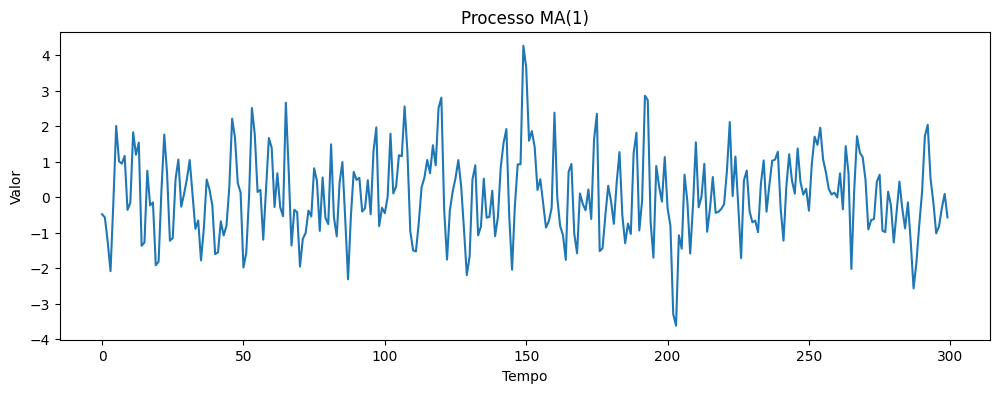

In [8]:
ma1 = np.array([1, 0.8])
ar_ma1 = np.array([1])

MA_object = ArmaProcess(ar_ma1, ma1)
x_ma1 = MA_object.generate_sample(nsample=300)

plt.figure(figsize=(12, 4))
plt.plot(x_ma1)
plt.title("Processo MA(1)")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

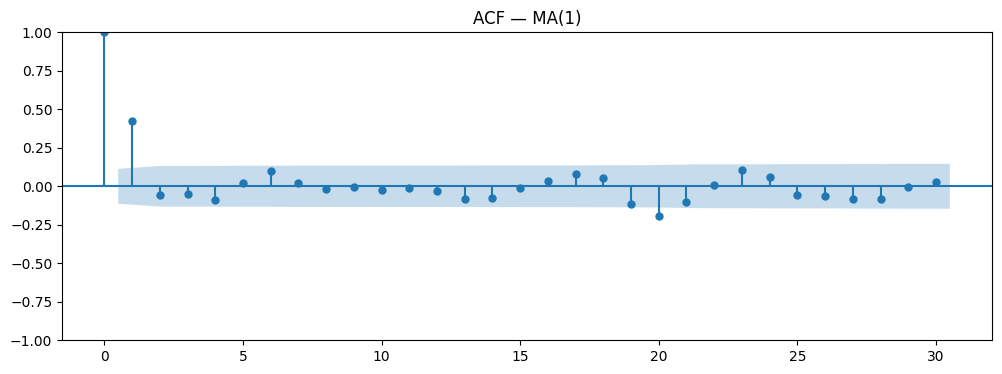

In [9]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(x_ma1, lags=30, ax=ax)
ax.set_title("ACF — MA(1)")
plt.show()

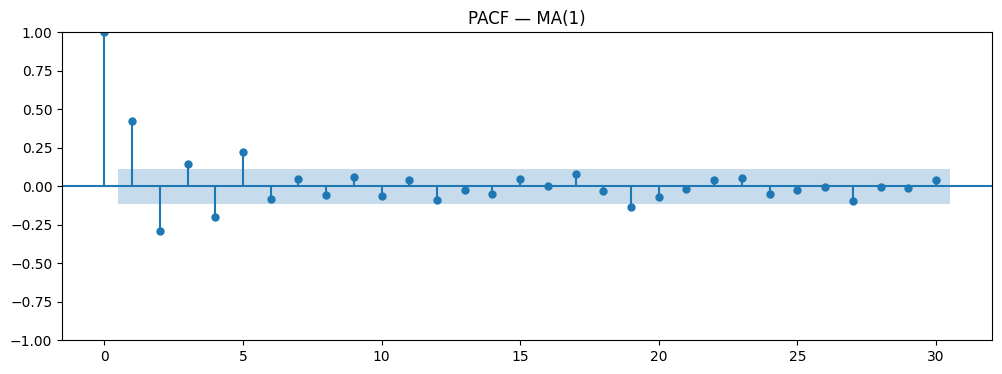

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(x_ma1, lags=30, ax=ax, method="ywm")
ax.set_title("PACF — MA(1)")
plt.show()

# 8. Exemplo 4 — AR(2)

Um processo AR(2) utiliza duas defasagens diretamente.

Em um exemplo bem comportado, esperamos que a **PACF apresente as principais correlações até o lag 2** e depois perca força.

Esse exemplo é especialmente útil para mostrar por que olhar apenas a ACF pode não ser suficiente.

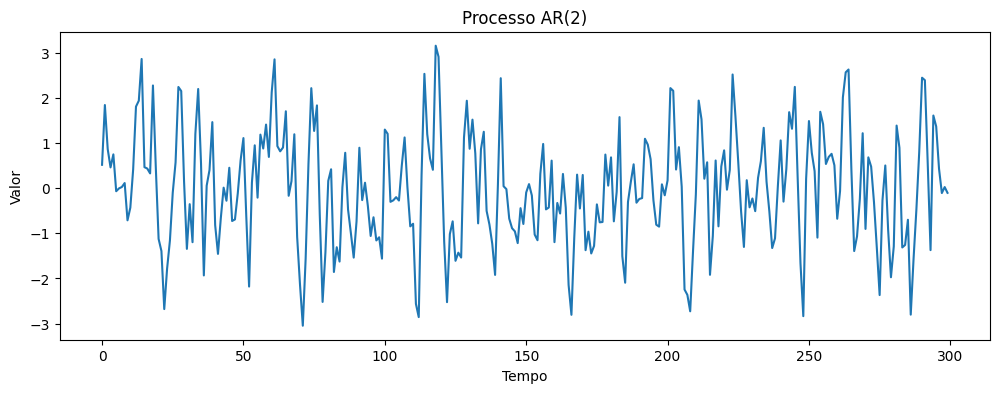

In [11]:
ar2_pos = np.array([1, -0.6, 0.25])
ma2_pos = np.array([1])

AR2_object = ArmaProcess(ar2_pos, ma2_pos)
x_ar2 = AR2_object.generate_sample(nsample=300)

plt.figure(figsize=(12, 4))
plt.plot(x_ar2)
plt.title("Processo AR(2)")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

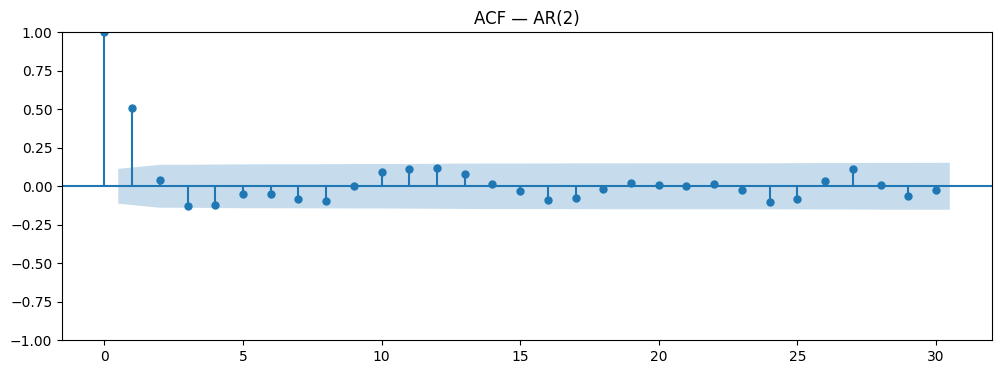

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(x_ar2, lags=30, ax=ax)
ax.set_title("ACF — AR(2)")
plt.show()

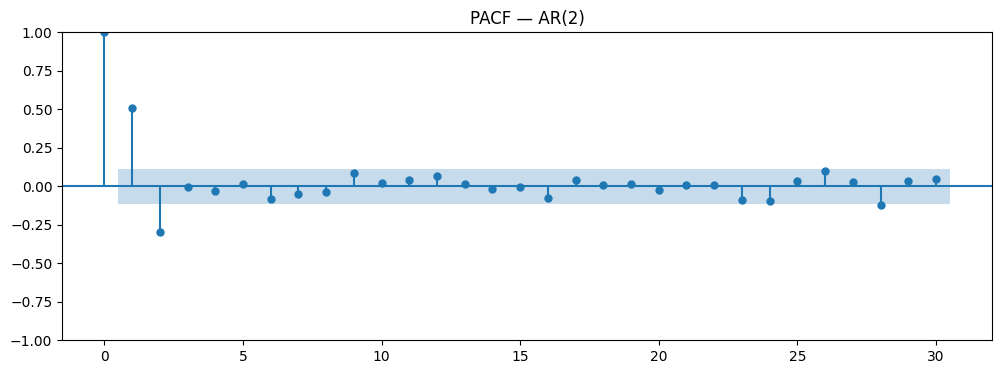

In [13]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(x_ar2, lags=30, ax=ax, method="ywm")
ax.set_title("PACF — AR(2)")
plt.show()

# 9. Exemplo 5 — AR(1) com coeficiente positivo


Como o coeficiente é positivo, valores altos tendem a ser seguidos por valores altos, e valores baixos por valores baixos.

A dependência vai sendo propagada para lags maiores.

### Padrão esperado

- ACF: decaimento gradual;
- PACF: destaque principalmente no lag 1.

Esse é um dos exemplos clássicos para compreender a diferença entre ACF e PACF.

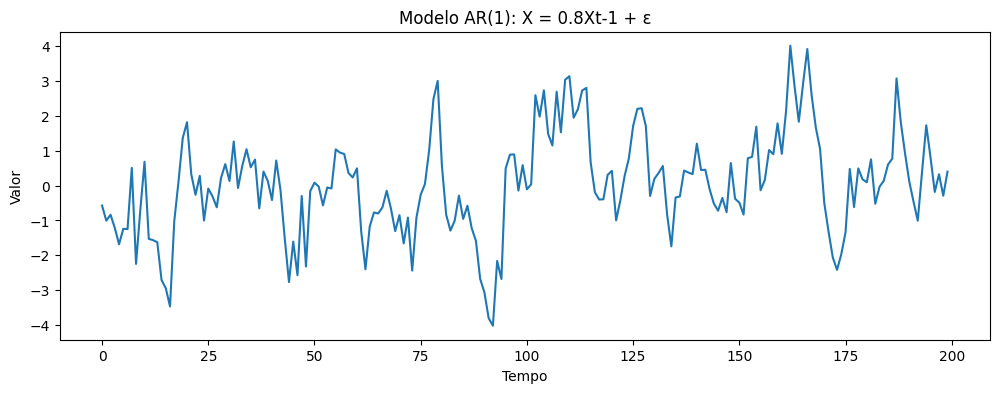

In [14]:
ar1 = np.array([1, -0.8])
ma1 = np.array([1])

AR_object1 = ArmaProcess(ar1, ma1)
x2 = AR_object1.generate_sample(nsample=200)

plt.figure(figsize=(12, 4))
plt.plot(x2)
plt.title("Modelo AR(1): X = 0.8Xt-1 + ε")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

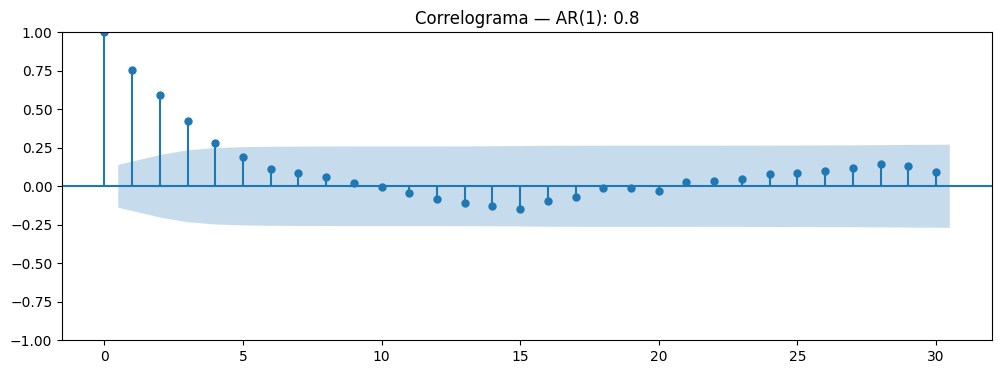

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(x2, lags=30, ax=ax)
ax.set_title("Correlograma — AR(1): 0.8")
plt.show()

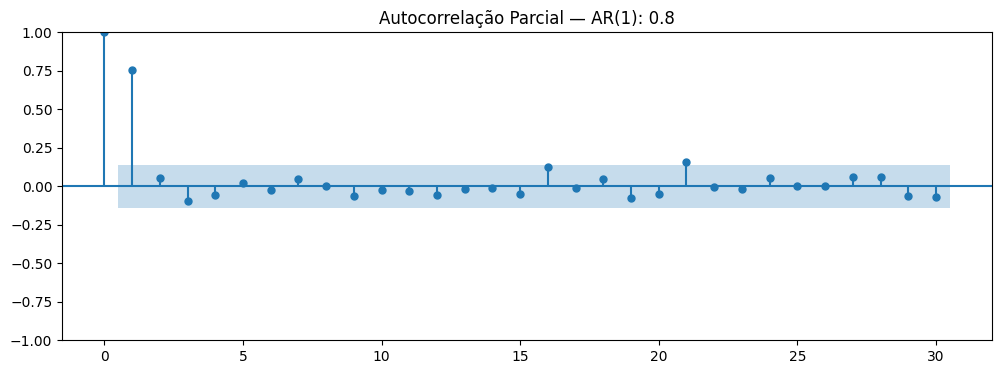

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(x2, lags=30, ax=ax, method="ywm")
ax.set_title("Autocorrelação Parcial — AR(1): 0.8")
plt.show()

# 10. Exemplo 6 — AR(1) com coeficiente negativo


Agora, o sinal negativo produz uma dinâmica de alternância.

Quando um valor está acima da média, o próximo tende a se deslocar para o lado oposto; depois, o processo tende novamente a alternar.

### No correlograma

A ACF tende a alternar sinais:

- lag 1: negativo;
- lag 2: positivo;
- lag 3: negativo;
- ...

Esse comportamento é uma excelente demonstração de que o sinal da autocorrelação contém informação sobre a dinâmica temporal.

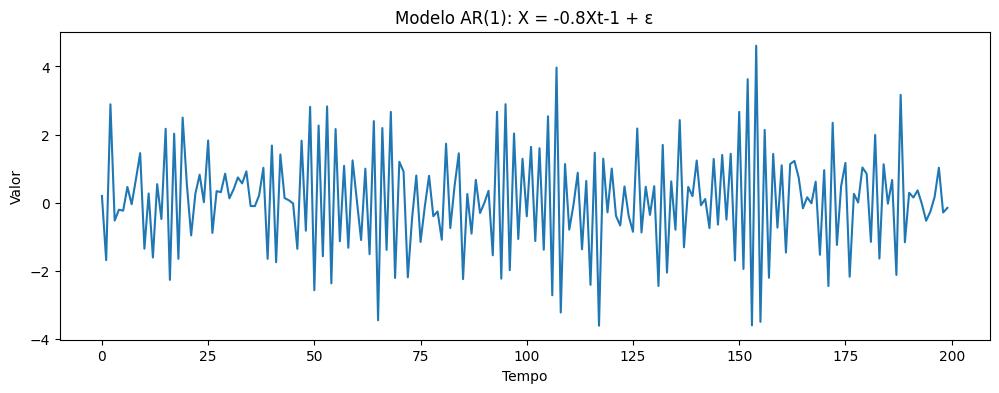

In [17]:
ar2 = np.array([1, 0.8])
ma2 = np.array([1])

AR_object2 = ArmaProcess(ar2, ma2)
x3 = AR_object2.generate_sample(nsample=200)

plt.figure(figsize=(12, 4))
plt.plot(x3)
plt.title("Modelo AR(1): X = -0.8Xt-1 + ε")
plt.xlabel("Tempo")
plt.ylabel("Valor")
plt.show()

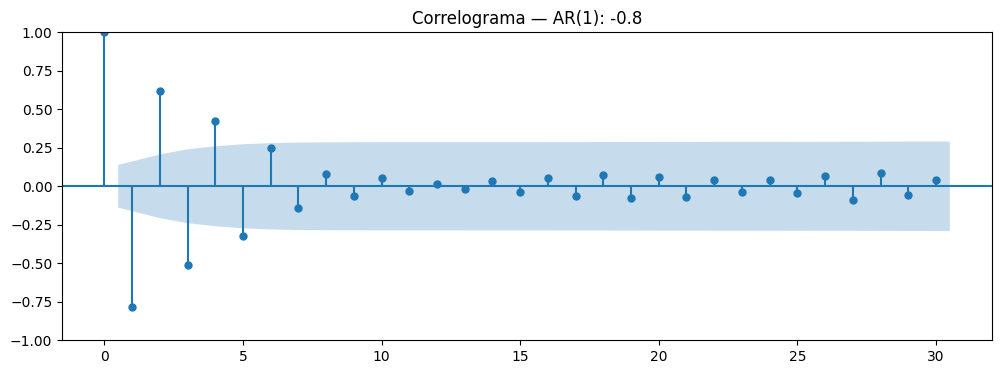

In [18]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(x3, lags=30, ax=ax)
ax.set_title("Correlograma — AR(1): -0.8")
plt.show()

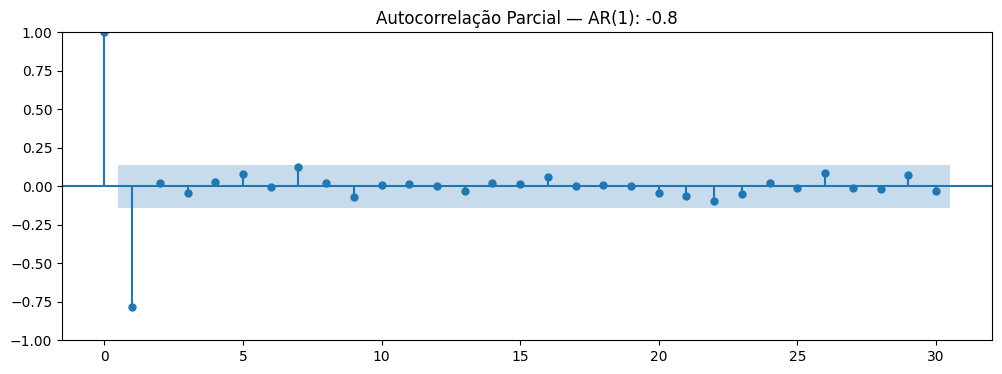

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_pacf(x3, lags=30, ax=ax, method="ywm")
ax.set_title("Autocorrelação Parcial — AR(1): -0.8")
plt.show()

# 11. ACF × PACF — quadro-resumo

| Estrutura | ACF | PACF |
|---|---|---|
| Ruído branco | Sem autocorrelações significativas após lag 0 | Sem autocorrelações significativas após lag 0 |
| AR(1) | Decaimento gradual | Corte aproximadamente após lag 1 |
| AR(2) | Decaimento gradual/oscilatório | Corte aproximadamente após lag 2 |
| MA(1) | Corte aproximadamente após lag 1 | Decaimento gradual |
| Sazonalidade | Picos em lags sazonais | Pode revelar estrutura complementar |
| Passeio aleatório | Decaimento muito lento | Comportamento compatível com não estacionaridade |

> Essas características são **heurísticas para identificação**. Em séries reais, amostra, ruído, tendência, sazonalidade e outras estruturas podem tornar o padrão menos nítido.

# 12. Estacionaridade

Antes de interpretar ACF e PACF como ferramentas de identificação de uma estrutura temporal, precisamos discutir **estacionaridade**.

Uma série é fracamente estacionária quando, de forma simplificada:

- sua média não muda ao longo do tempo;
- sua variância permanece estável;
- a covariância entre dois pontos depende apenas da distância temporal entre eles, e não do instante específico.

### Por que isso importa?

Se a série não é estacionária, a autocorrelação pode apresentar comportamento persistente simplesmente porque existe uma tendência ou uma raiz unitária.

O **passeio aleatório** será nosso exemplo clássico de série não estacionária.

# 14. Teste Augmented Dickey-Fuller (ADF)

Na prática, o teste mais utilizado é o **Augmented Dickey-Fuller (ADF)**.



### Hipóteses

As hipóteses fundamentais continuam sendo:

- **H₀:**  A série possui raiz unitária (não é estacionária).
- **H₁:** A série não possui raiz unitária (é estacionária).

A principal diferença é que o ADF é uma extensão do DF para situações em que há autocorrelação serial nos erros.

No `statsmodels`, podemos executar o teste com `adfuller()`.

# 15. Comparando DF e ADF

Para deixar a diferença operacional clara:

- **DF:** versão simples, sem defasagens adicionais das diferenças;
- **ADF:** versão aumentada, incluindo defasagens de ΔX para lidar com autocorrelação dos resíduos.

No `statsmodels`, podemos aproximar o DF usando:

```python
adfuller(x, maxlag=0, regression="c", autolag=None)
```

e aplicar o ADF com seleção automática de defasagens, por exemplo:

```python
adfuller(x, regression="c", autolag="AIC")
```

A escolha de `regression` também é importante:

- `"n"`: sem constante e sem tendência;
- `"c"`: constante;
- `"ct"`: constante + tendência;
- `"ctt"`: constante + tendência + tendência quadrática.

A especificação deve ser coerente com a natureza da série.

In [22]:
def resultado_adf(nome, serie, maxlag=None, regression="c", autolag="AIC"):
    resultado = adfuller(
        serie,
        maxlag=maxlag,
        regression=regression,
        autolag=autolag
    )

    estatistica, pvalor, usedlag, nobs, valores_criticos = resultado[:5]

    print(f"--- {nome} ---")
    print(f"Estatística do teste: {estatistica:.4f}")
    print(f"p-valor: {pvalor:.4f}")
    print(f"Defasagens utilizadas: {usedlag}")
    print(f"Observações: {nobs}")
    print("Valores críticos:")
    for nivel, valor in valores_criticos.items():
        print(f"  {nivel}: {valor:.4f}")

    if pvalor < 0.05:
        print("Conclusão: rejeitamos H0 ao nível de 5%. A série não possui raiz unitária (é estacionária)")
    else:
        print("Conclusão: não rejeitamos H0 ao nível de 5%. A série possui raiz unitária (não é estacionária).")

## 16. Aplicando o DF simples e o ADF ao AR(1)

O AR(1) com coeficiente 0.8 é estacionário porque o coeficiente está dentro da condição usual de estacionaridade do AR(1), \(|\phi|<1\).

Vamos comparar:

1. DF simples (`maxlag=0`);
2. ADF com seleção de defasagens.

In [24]:
resultado_adf(
    "AR(1) — Dickey-Fuller simples",
    x2,
    maxlag=0,
    regression="c",
    autolag=None
)

print()



--- AR(1) — Dickey-Fuller simples ---
Estatística do teste: -5.2466
p-valor: 0.0000
Defasagens utilizadas: 0
Observações: 199
Valores críticos:
  1%: -3.4636
  5%: -2.8762
  10%: -2.5746
Conclusão: rejeitamos H0 ao nível de 5%. A série não possui raiz unitária (é estacionária)



# 17. Testando o passeio aleatório


In [25]:
np.random.seed(0)

e = np.random.normal(size=200)
x4 = np.cumsum(e)

resultado_adf(
    "Passeio aleatório — DF simples",
    x4,
    maxlag=0,
    regression="c",
    autolag=None
)

print()


--- Passeio aleatório — DF simples ---
Estatística do teste: -1.3903
p-valor: 0.5869
Defasagens utilizadas: 0
Observações: 199
Valores críticos:
  1%: -3.4636
  5%: -2.8762
  10%: -2.5746
Conclusão: não rejeitamos H0 ao nível de 5%. A série possui raiz unitária (não é estacionária).



# 18. Diferenciação do passeio aleatório

Uma forma clássica de transformar o passeio aleatório em uma série estacionária é trabalhar com a primeira diferença:

A diferença do passeio aleatório é o próprio choque aleatório.

Vamos verificar isso graficamente e com o ADF.

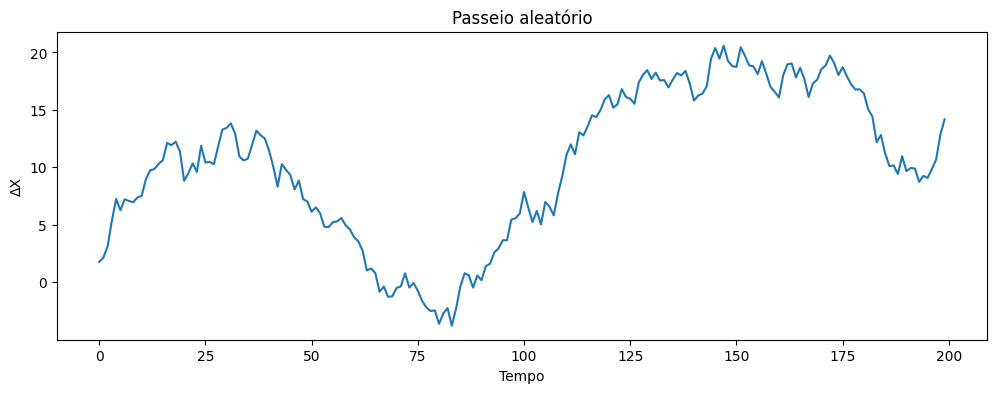

In [29]:
plt.figure(figsize=(12, 4))
plt.plot(x4)
plt.title("Passeio aleatório")
plt.xlabel("Tempo")
plt.ylabel("ΔX")
plt.show()

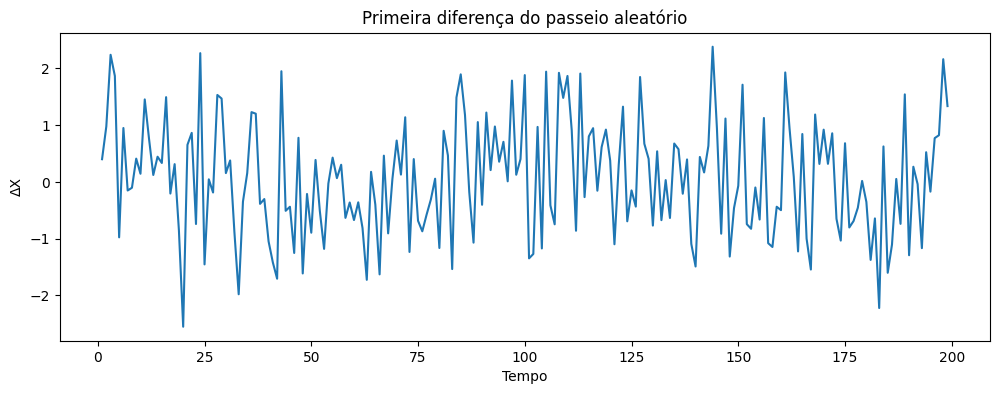

In [26]:
dx4 = pd.Series(x4).diff().dropna()

plt.figure(figsize=(12, 4))
plt.plot(dx4)
plt.title("Primeira diferença do passeio aleatório")
plt.xlabel("Tempo")
plt.ylabel("ΔX")
plt.show()

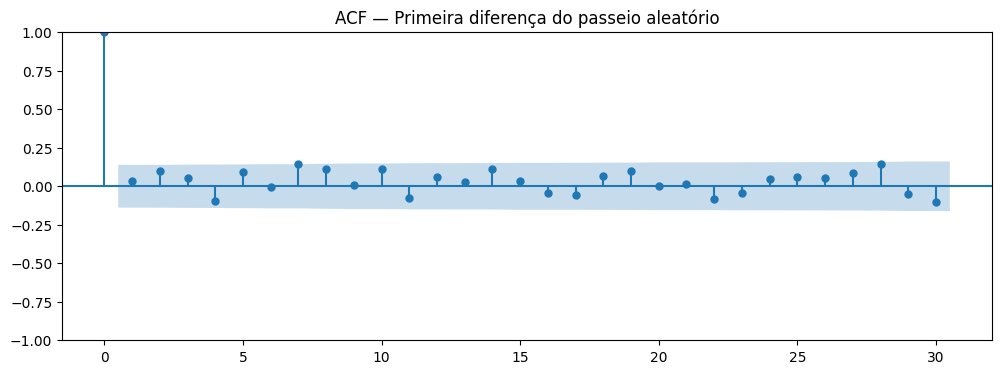

In [27]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(dx4, lags=30, ax=ax)
ax.set_title("ACF — Primeira diferença do passeio aleatório")
plt.show()

In [28]:
resultado_adf(
    "Primeira diferença do passeio aleatório — ADF",
    dx4,
    regression="c",
    autolag="AIC"
)

--- Primeira diferença do passeio aleatório — ADF ---
Estatística do teste: -13.4669
p-valor: 0.0000
Defasagens utilizadas: 0
Observações: 198
Valores críticos:
  1%: -3.4638
  5%: -2.8763
  10%: -2.5746
Conclusão: rejeitamos H0 ao nível de 5%. A série não possui raiz unitária (é estacionária)


# 19. Agora sim: Ruído Branco


### O que esperamos?

- ACF próxima de zero para os lags maiores que zero;
- PACF próxima de zero para os lags maiores que zero;
- ausência de estrutura temporal previsível.

O ruído branco é, portanto, uma excelente referência para entender o que significa **não haver autocorrelação significativa**.

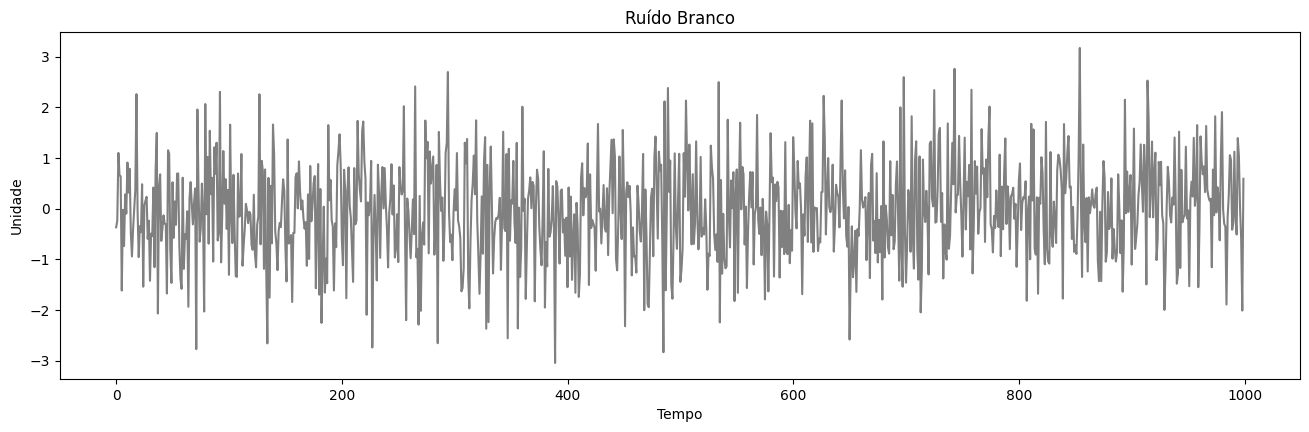

In [30]:
whitenoise = pd.Series(norm.rvs(size=1000))

whitenoise.plot(
    ylabel="Unidade",
    xlabel="Tempo",
    figsize=(16, 4.5),
    color="gray",
    title="Ruído Branco"
)
plt.show()

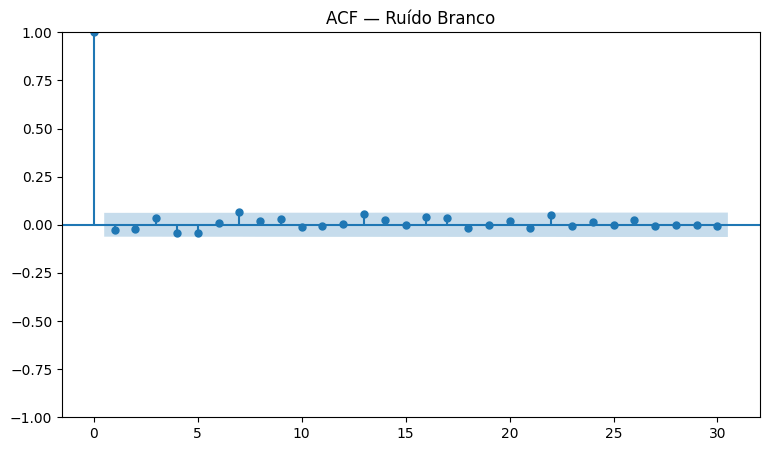

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_acf(whitenoise, ax=ax)
ax.set_title("ACF — Ruído Branco")
plt.show()

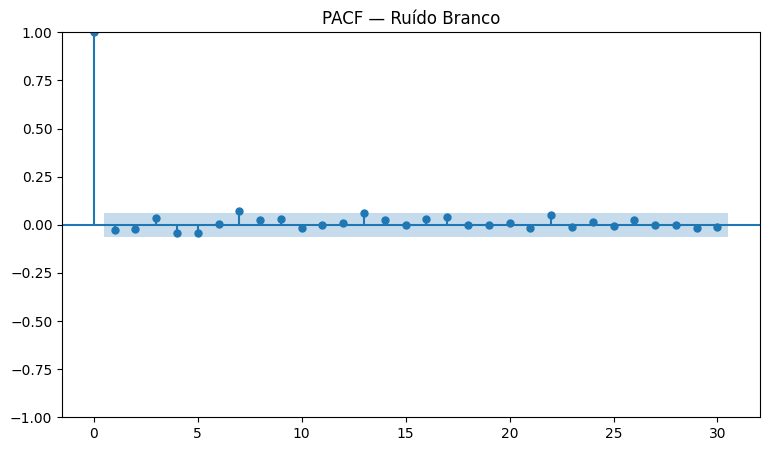

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_pacf(whitenoise, ax=ax, method="ywm")
ax.set_title("PACF — Ruído Branco")
plt.show()

In [33]:
resultado_adf(
    "Ruído branco — ADF",
    whitenoise,
    regression="c",
    autolag="AIC"
)

--- Ruído branco — ADF ---
Estatística do teste: -32.4426
p-valor: 0.0000
Defasagens utilizadas: 0
Observações: 999
Valores críticos:
  1%: -3.4369
  5%: -2.8644
  10%: -2.5683
Conclusão: rejeitamos H0 ao nível de 5%. A série não possui raiz unitária (é estacionária)


# 21. Síntese da aula

## Como interpretar ACF e PACF?

### ACF
Pergunta:

> **Quanto \(X_t\) está associado a \(X_{t-k}\)?**

É especialmente útil para observar:

- persistência temporal;
- sazonalidade;
- padrões de decaimento;
- possíveis estruturas MA.

### PACF
Pergunta:

> **Quanto \(X_t\) está associado diretamente a \(X_{t-k}\), depois de controlar os lags intermediários?**

É especialmente útil para:

- identificar possíveis ordens de processos AR;
- separar uma associação direta de uma associação propagada por lags intermediários.

## E a estacionaridade?

A ACF pode dar pistas, mas a decisão não deve depender apenas do correlograma.

O teste **DF/ADF** fornece uma abordagem formal para investigar raiz unitária:

- **H₀:** raiz unitária;
- **p < 0,05:** rejeitamos H₀;
- **p ≥ 0,05:** não rejeitamos H₀.

## Mapa mental

**Série → gráfico → ACF/PACF → estacionaridade → DF/ADF → transformação, se necessária → modelagem**

> O próximo passo, em uma disciplina de séries temporais, é combinar essas evidências com o conhecimento do problema e com critérios de diagnóstico para construir modelos adequados.